# Notebook 4: Chronic Kidney Disease Prediction
**Dataset**: CKD Dataset (UCI)
**Target**: classification (ckd / notckd)
**Model**: Random Forest Classifier + GridSearchCV Tuning
**Note**: Heavy missing values — careful imputation required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Step 1: Load Data

In [2]:
df = pd.read_csv('../datasets/kidney_disease.csv')
df.columns = df.columns.str.strip()
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
print('Shape:', df.shape)
print('\nMissing (%):')
print((df.isnull().sum()/len(df)*100).sort_values(ascending=False).head(10))

Shape: (400, 25)

Missing (%):
rbc     38.00
rc      32.50
wc      26.25
pot     22.00
sod     21.75
pcv     17.50
pc      16.25
hemo    13.00
su      12.25
sg      11.75
dtype: float64


## Step 2: EDA

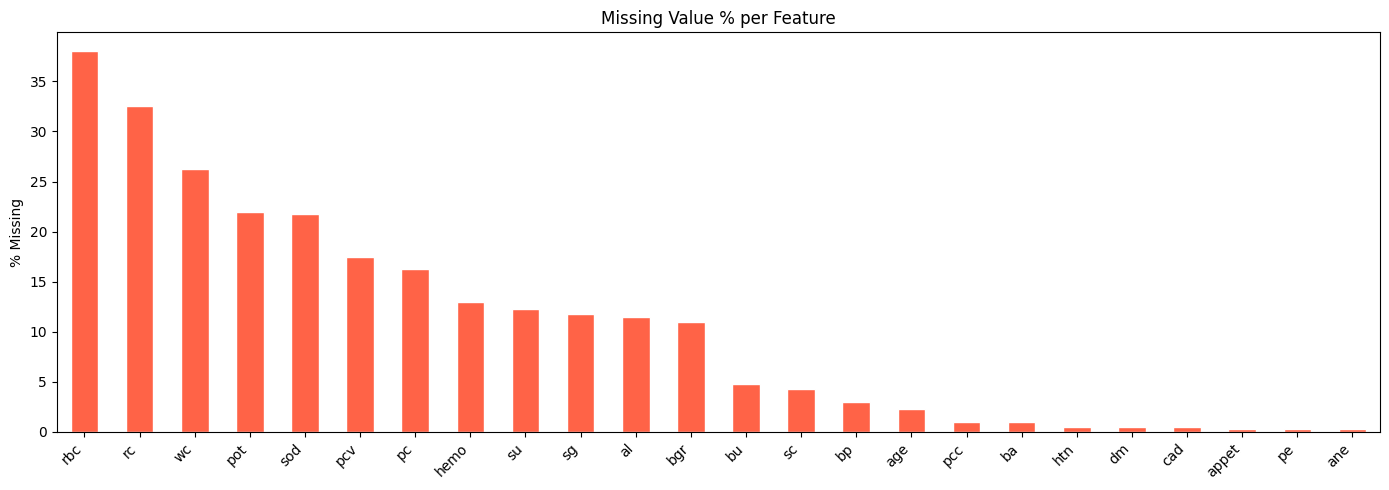

In [3]:
missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_pct[missing_pct>0].plot(kind='bar', color='tomato', edgecolor='white', figsize=(14,5))
plt.title('Missing Value % per Feature')
plt.ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
print('Class distribution:\n', df['classification'].value_counts())

Class distribution:
 classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


## Step 3: Preprocessing

In [5]:
df['classification'] = df['classification'].str.strip().map({'ckd':1,'notckd':0})
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = le.fit_transform(df[col])
X = df.drop('classification', axis=1)
y = df['classification']
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (320, 24), Test: (80, 24)


## Step 4: Baseline Model

In [6]:
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f'Baseline Accuracy : {baseline_acc:.4f}')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')

Baseline Accuracy : 1.0000
Baseline ROC-AUC  : 1.0000


## Step 5: Hyperparameter Tuning (GridSearchCV)

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', f'{grid_search.best_score_:.4f}')

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV ROC-AUC: 1.0000


## Step 6: Tuned Model Evaluation

In [8]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)
print(f'Tuned Accuracy : {tuned_acc:.4f}  (Baseline: {baseline_acc:.4f})  Gain: {tuned_acc - baseline_acc:+.4f}')
print(f'Tuned ROC-AUC  : {tuned_auc:.4f}  (Baseline: {baseline_auc:.4f})  Gain: {tuned_auc - baseline_auc:+.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['Not CKD','CKD']))

Tuned Accuracy : 1.0000  (Baseline: 1.0000)  Gain: +0.0000
Tuned ROC-AUC  : 1.0000  (Baseline: 1.0000)  Gain: +0.0000

Classification Report:
               precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



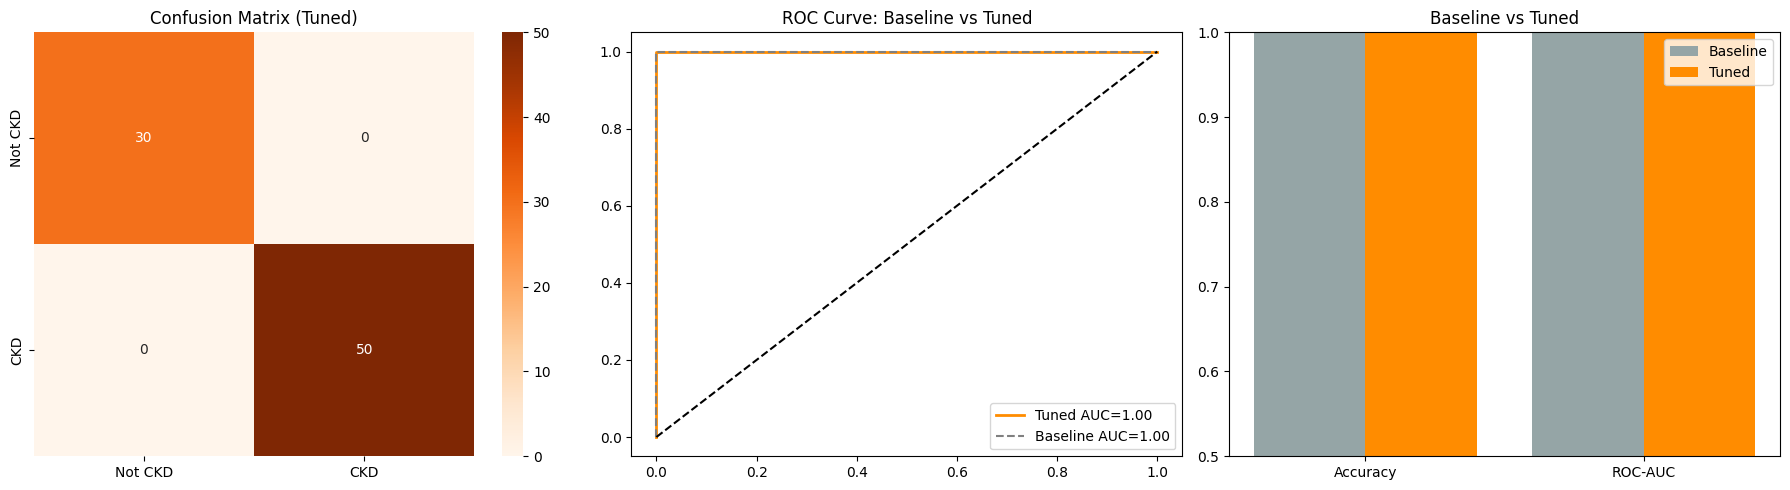

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Not CKD','CKD'], yticklabels=['Not CKD','CKD'])
axes[0].set_title('Confusion Matrix (Tuned)')
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Tuned AUC={tuned_auc:.2f}')
fpr_b, tpr_b, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:,1])
axes[1].plot(fpr_b, tpr_b, color='gray', lw=1.5, linestyle='--', label=f'Baseline AUC={baseline_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve: Baseline vs Tuned')
axes[1].legend()
x = np.arange(2)
axes[2].bar(x-0.2, [baseline_acc, baseline_auc], 0.4, label='Baseline', color='#95a5a6')
axes[2].bar(x+0.2, [tuned_acc, tuned_auc], 0.4, label='Tuned', color='darkorange')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Accuracy','ROC-AUC'])
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Baseline vs Tuned')
axes[2].legend()
plt.tight_layout()
plt.show()

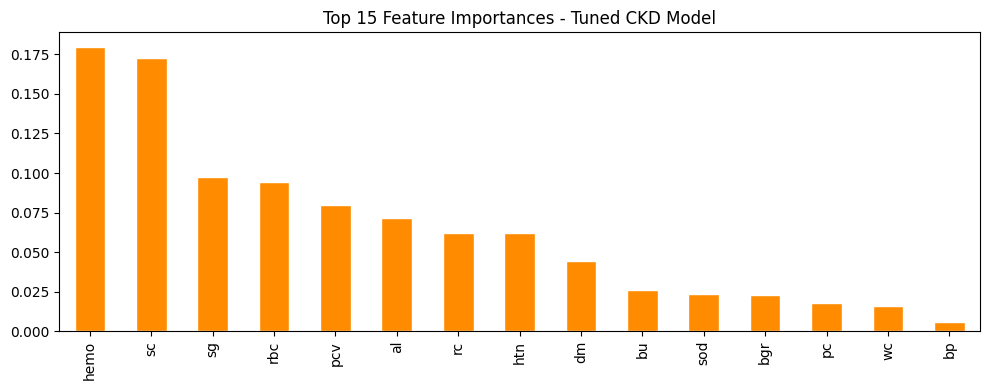

In [10]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
feat_imp.plot(kind='bar', color='darkorange', edgecolor='white', figsize=(10,4))
plt.title('Top 15 Feature Importances - Tuned CKD Model')
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [11]:
joblib.dump(model, '../models/kidney_model.pkl')
joblib.dump(scaler, '../models/kidney_scaler.pkl')
joblib.dump(imputer, '../models/kidney_imputer.pkl')
print('Kidney tuned model, scaler, and imputer saved!')

Kidney tuned model, scaler, and imputer saved!
